# Atividade Avaliativa - Decodificação de Letras EMNIST

Você já treinou uma rede neural para reconhecer dígitos manuscritos usando o conjunto de dados MNIST. Isso lhe proporcionou um ambiente limpo e estruturado para se familiarizar com a classificação de imagens.

Agora é hora de algo mais desafiador.
Você aplicará essas mesmas habilidades a um novo conjunto de dados: o **EMNIST**. Ele contém **letras** manuscritas em vez de dígitos. Os dados são mais complexos e variados, e existem 26 classes em vez de 10, então seu modelo precisará trabalhar um pouco mais para acertar as coisas.

Ao final do laboratório, você colocará seu modelo treinado à prova decodificando uma mensagem manuscrita.



**O Que Você Fará Nesta Tarefa**

  * Carregar e explorar o conjunto de dados EMNIST Letters para entender sua estrutura e conteúdo

  * Pré-processar as imagens corrigindo sua orientação, normalizando os valores dos pixels e convertendo-as em tensores

  * Construir uma rede neural de múltiplas camadas que possa classificar letras manuscritas



  * Treinar e avaliar seu modelo em exemplos não vistos

  * Usar seu modelo treinado para decodificar uma mensagem manuscrita secreta

---
<a name='submission'></a>

<h4 style="color:green; font-weight:bold;">DICAS PARA O SUCESSO NA AVALIAÇÃO DA SUA TAREFA:</h4>

* Em cada célula de exercício, procure pelos comentários `### COMECE SEU CÓDIGO ###` e `### TERMINE SEU CÓDIGO AQUI ###`. Eles indicam onde você deve escrever o código da solução. **Não adicione ou altere nenhum código que esteja fora desses comentários**.

* Você pode adicionar novas células para experimentar, mas elas serão ignoradas durante a avaliação; portanto, não dependa de células recém-criadas para hospedar seu código de solução, use os locais fornecidos para isso.

* Evite o uso de variáveis globais, a menos que seja absolutamente necessário. Vou avaliar seu código em um ambiente isolado sem executar todas as células desde o topo. Como resultado, variáveis globais podem estar indisponíveis no momento da correção. Variáveis globais que devem ser utilizadas estarão definidas em MAIÚSCULAS.
---

## Sumário

  - [Importações](#imports)
  - [1. Imagens de Letras](#1)
      - [1.1 Carregar o Conjunto de Dados](#1.1)
      - [1.2 Explorar os Dados Brutos](#1.2)
      - [1.3 Pré-processamento das Imagens](#1.3)
      - [1.4 Carregando Dados em Lotes (*Batches*)](#1.4)
          - **[Exercício 1 - create\_emnist\_dataloaders](#ex1)**
  - [2. Construindo a Rede Neural](#2)
      - **[Exercício 2 - initialize\_emnist\_model](#ex2)**
  - [3. Treinamento e Avaliação do Modelo](#3)
      - [3.1 Treinando o Modelo](#3.1)
          - **[Exercício 3 - train\_epoch](#ex3)**
      - [3.2 Avaliação do Modelo](#3.2)
          - **[Exercício 4 - evaluate](#ex4)**
      - [3.3 Juntando Tudo](#3.3)
          - **[Exercício 5 - train\_and\_evaluate](#ex5)**
  - [4. Decodificando a Mensagem Secreta](#4)

<a name='imports'></a>
## Importar as bibliotecas necessárias

In [1]:
import os

def download_files(filenames):
    """
    Baixa uma lista de arquivos do repositório do curso se eles não existirem localmente.
    """
    # URL base onde os arquivos do curso estão hospedados no GitHub
    base_url = "https://raw.githubusercontent.com/fabiobento/dnn-course-2026-1/main/"
    
    for filename in filenames:
        # Verifica se o arquivo já está presente na pasta atual para evitar downloads repetidos
        if not os.path.exists(filename):
            url = f"{base_url}{filename}"
            print(f"Baixando {filename}...")
            
            # Executa o comando 'wget' do sistema operacional para baixar o arquivo
            # -q: modo silencioso (quiet) | -O: define o nome do arquivo de saída
            os.system(f"wget -q {url} -O {filename}")
        else:
            print(f"O arquivo '{filename}' já existe localmente. Pulando...")




In [2]:
# Lista de arquivos auxiliares indispensáveis para a execução correta deste notebook:
# Inclui scripts de utilitários (.py), dados serializados (.pkl) e o dataset compactado (.tar.gz)
arquivos_necessários = [
    'helper_utils_4.py',        # Script com funções auxiliares de visualização e cálculo
    'hidden_message_images.pkl', # Arquivo de dados contendo imagens para um desafio/exercício específico
]

# Chama a função para baixar os arquivos listados acima a partir do repositório remoto
download_files(arquivos_necessários)

O arquivo 'helper_utils_4.py' já existe localmente. Pulando...
O arquivo 'hidden_message_images.pkl' já existe localmente. Pulando...


In [3]:
import os                             # Fornece funções para interagir com o sistema operacional (caminhos de arquivos, pastas)
import torch                          # Biblioteca principal do PyTorch para computação tensorial e redes neurais
from torchvision import transforms    # Contém ferramentas comuns de transformação de imagem para pré-processamento
from torchvision import datasets     # Fornece acesso a conjuntos de dados populares (como MNIST, CIFAR10, etc.)
from torch.utils.data import DataLoader # Facilita o carregamento de dados em lotes (batches) e o embaralhamento
import torch.nn as nn                 # Contém os blocos de construção para camadas de redes neurais (Linear, Conv2d, etc.)
from torch import optim               # Inclui algoritmos de otimização como SGD, Adam e RMSprop
import torchvision.transforms.functional as F # Versão funcional das transformações (permite controle mais granular sobre as imagens)

In [4]:
import helper_utils_4  # Importa o módulo de utilitários personalizados para visualização e métricas

Verifique se o `DEVICE` disponível é "cuda" ou "cpu"

In [5]:
# Define o dispositivo onde os cálculos serão realizados. 
# Verifica se uma GPU (CUDA) está disponível; caso contrário, utiliza o processador (CPU).
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Exibe qual dispositivo foi selecionado para o treinamento/inferência
print(f"Utilizando o dispositivo: {DEVICE}")

Utilizando o dispositivo: cuda


<a name='1'></a>

## 1 - Imagens de Letras

Você começará carregando o conjunto de dados EMNIST, concentrando-se no subconjunto **Letters**.
Ele estende o MNIST fornecendo **letras** manuscritas em vez de dígitos.
Este subconjunto inclui **124.800 imagens em tons de cinza** para treinamento e **20.800 imagens** para teste, cada uma rotulada com uma de **26 classes de letras minúsculas**.

<a name='1.1'></a>

### 1.1 - Carregar o Conjunto de Dados

Antes de poder trabalhar com os dados do EMNIST Letters, você precisará garantir que eles estejam disponíveis em seu espaço de trabalho.
Se ainda não estiverem lá, você pode baixá-los usando `torchvision.datasets.EMNIST`.
Você usará a divisão `letters` do conjunto de dados EMNIST, que inclui caracteres manuscritos de 'a' a 'z'.
Para selecionar este subconjunto, certifique-se de passar `split='letters'` ao construtor `EMNIST`.

In [6]:
# Define o caminho onde os dados do EMNIST serão armazenados
data_path = './EMNIST_data'

# Verifica se a pasta de dados existe para evitar o download repetido
if os.path.exists(data_path) and os.path.isdir(data_path):
    download = False
    print("Pasta de dados EMNIST encontrada localmente. Carregando do disco local.\n")
else:
    download = True
    print("Pasta de dados EMNIST não encontrada localmente. Iniciando o download.\n")


# Carrega o conjunto de treinamento do EMNIST Letters (Letras)
train_dataset = datasets.EMNIST(
    root=data_path,    # Especifica o diretório raiz para o conjunto de dados
    split='letters',   # Usa o subconjunto 'letters' (26 classes de letras minúsculas)
    train=True,        # Indica que este é o conjunto de treinamento
    download=download  # Baixa o dataset se necessário (com base na verificação anterior)
)

# Carrega o conjunto de teste do EMNIST Letters
test_dataset = datasets.EMNIST(
    root=data_path,    # Especifica o diretório raiz para o conjunto de dados
    split='letters',   # Usa o subconjunto 'letters' (26 classes de letras minúsculas)
    train=False,       # Indica que este é o conjunto de teste
    download=download  # Baixa o dataset se necessário
)

Pasta de dados EMNIST encontrada localmente. Carregando do disco local.



<a name='1.2'></a>

### 1.2 - Explorar os Dados Brutos

Agora que seu conjunto de dados está carregado, reserve um momento para ver com o que você está trabalhando. Visualizar algumas amostras ajudará você a entender como as letras são escritas e quais desafios seu modelo pode enfrentar.

Comece exibindo uma imagem de amostra usando `helper_utils.visualize_image`.
Em seguida, tente alterar o valor do índice para visualizar diferentes exemplos.

À medida que você explora, considere:

  * Essas letras se parecem com o que você esperava?
  * Há algo na aparência delas que possa tornar o treinamento ou a interpretação mais difícil?

In [7]:
# CÉLULA EDITÁVEL:

index = 90000  # Escolha um índice (posição) do conjunto de treinamento para visualizar

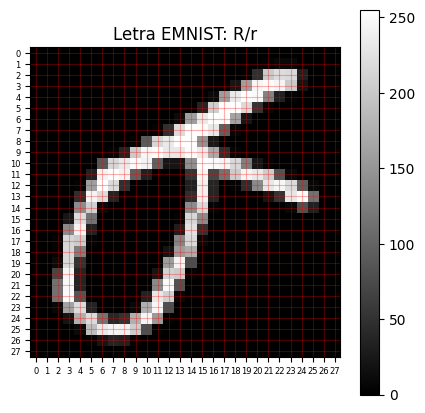


 Tipo da imagem: <class 'PIL.Image.Image'>


In [8]:
img, label = train_dataset[index]  # Extrai a imagem e seu respectivo rótulo (classe) do dataset

helper_utils_4.visualize_image(img, label)  # Exibe a imagem na tela com seu rótulo correspondente

# A imagem original é armazenada como um objeto PIL Image. 
# Será necessário convertê-la em um tensor do PyTorch antes de iniciar o treinamento.
print(f"\n Tipo da imagem: {type(img)}")

Você provavelmente notará que as letras manuscritas aparecem rotacionadas ou invertidas. Tecnicamente, um modelo ainda pode aprender com elas, desde que **cada imagem seja orientada da mesma maneira**. O modelo não "sabe" como é uma letra orientada corretamente; ele apenas aprende padrões que são consistentes em todo o conjunto de dados.

No entanto, isso pode tornar mais difícil para *você* inspecionar visualmente ou interpretar as amostras. Na próxima etapa, você usará uma função auxiliar para exibir as letras em uma orientação mais familiar, para que fiquem mais fáceis de visualizar. Essa correção serve apenas para a visualização. Os dados subjacentes permanecerão inalterados e o modelo ainda treinará neles exatamente como foram fornecidos.

<a name='1.3'></a>

### 1.3 - Pré-processamento das Imagens

Antes de poder treinar seu modelo, você precisa converter as imagens em um formato com o qual o PyTorch possa trabalhar e aplicar a normalização para ajudar o modelo a aprender de forma mais eficaz.

Para fazer isso, você usará `transforms.Compose` para aplicar uma sequência de etapas de pré-processamento:

  * `transforms.ToTensor()` converte a imagem de um formato PIL para um tensor do PyTorch.
  * `transforms.Normalize(mean, std)` escala os valores dos pixels usando valores de média e desvio padrão pré-calculados.

A normalização mantém os valores dos pixels dentro de uma faixa consistente, o que melhora a estabilidade numérica e ajuda seu modelo a treinar de forma mais rápida e confiável.

Essas transformações são aplicadas automaticamente **cada vez que uma amostra é carregada do conjunto de dados**, garantindo que todos os dados passados para o modelo estejam padronizados e prontos para treinamento ou avaliação.

In [9]:
# Média (mean) e Desvio Padrão (std) pré-calculados para o conjunto de dados EMNIST Letters.
# Esses valores são usados para padronizar os dados de entrada.
mean = (0.1736,)
std = (0.3317,)

# Cria uma composição de transformações que converte imagens em tensores e as normaliza
transform = transforms.Compose([
    # Converte as imagens para tensores do PyTorch e redimensiona os valores dos pixels para o intervalo [0, 1]
    transforms.ToTensor(),  
    # Aplica a normalização estatística usando a média e o desvio padrão definidos acima
    transforms.Normalize(mean=mean, std=std)   
])

# Atribui a transformação definida tanto ao conjunto de treinamento quanto ao de teste
train_dataset.transform = transform
test_dataset.transform = transform

Agora, dê outra olhada na mesma amostra.
Desta vez, você está vendo o tensor bruto após a aplicação das transformações.

In [10]:
# CÉLULA EDITÁVEL:

index = 90000  # Escolha um índice (posição) do conjunto de treinamento para visualizar

In [12]:
# Recupera o tensor da imagem transformada e seu respectivo rótulo do conjunto de treinamento
img_tensor, label = train_dataset[index]

# Exibe o tensor da imagem para visualizar os valores brutos (após a transformação e normalização)
# Note que os valores agora não estão mais entre 0 e 255, mas sim normalizados.
print(img_tensor)

tensor([[[-0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234],
         [-0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.4761, -0.4288, -0.4288, -0.5234, -0.5234, -0.5234, -0.5234],
         [-0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.4879,  0.0323,
           1.8648,  2.0894,  2.0421, -0.1450, -0.5234, -0.5234, -0.5234],
         [-0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0

Primeiro, cada valor de pixel (originalmente entre 0 e 255) foi escalonado para um intervalo entre 0 e 1. Em seguida, esses valores foram normalizados subtraindo a média dos valores de pixel do conjunto de dados e dividindo pelo seu desvio padrão.

É por isso que os números que você vê agora estão centrados em torno de 0 — alguns são negativos, outros positivos. Esses valores mostram o quanto cada pixel é mais claro ou mais escuro em comparação com a média do conjunto de dados. Essa etapa de normalização ajuda seu modelo a treinar de forma mais rápida e confiável.

Agora você pode visualizar uma das imagens transformadas usando a função `helper_utils_4.visualize_image`.

Como as imagens neste conjunto de dados não estão orientadas corretamente, você primeiro aplicará a função `correct_image_orientation`. Esta função usa transformações como `F.rotate` e `F.vflip` para exibir as letras em sua orientação adequada.

Tenha em mente que esta etapa é **apenas para visualização**. Ela ajuda você a interpretar as imagens com mais facilidade. O conjunto de dados em si permanece inalterado, e o modelo ainda treinará nos dados originais e não corrigidos.

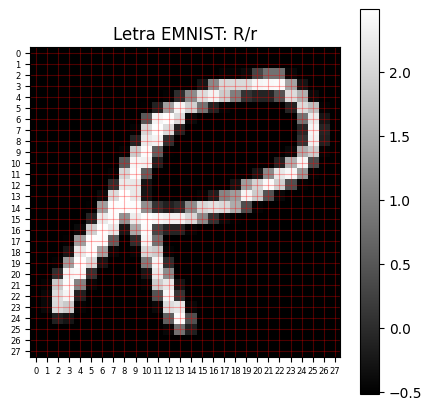

In [14]:
def correct_image_orientation(image):
    # Rotaciona a imagem em 90 graus no sentido horário
    rotated = F.rotate(image, 90) 
    # Inverte a imagem verticalmente (espelhamento)
    flipped = F.vflip(rotated) 
    return flipped

# Aplica a rotação e o espelhamento para corrigir a orientação da imagem
img_transformed = correct_image_orientation(img_tensor)

# Visualiza a imagem após as transformações
helper_utils_4.visualize_image(img_transformed, label)

<a name='1.4'></a>

### 1.4 - Carregando Dados em Lotes (*Batches*)

Sua rede neural precisa de entrada em um formato estruturado e consistente. Para conseguir isso, você usará o `DataLoader` do PyTorch para organizar suas imagens de letras pré-processadas em lotes — tornando o treinamento mais eficiente e fácil de gerenciar.

Nesta etapa, você completará a função `create_emnist_dataloaders` para configurar objetos `DataLoader` tanto para os dados de treinamento quanto para os de teste. Esses carregadores lidarão automaticamente com o agrupamento em lotes e o embaralhamento (*shuffling*), garantindo que seu modelo treine de forma eficaz e generalize bem.

<a name='ex1'></a>

### Exercício 1 - create_emnist_dataloaders 

Implemente a função `create_emnist_dataloaders` para criar objetos `DataLoader` do PyTorch para os conjuntos de dados de treinamento e teste do EMNIST.

**Sua tarefa:**

  * Crie o `train_dataloader` e o `test_dataloader` usando a classe `DataLoader` de `torch.utils.data`.
      * Defina o parâmetro `shuffle` adequadamente para cada conjunto de dados.
      * Use o parâmetro `batch_size` para definir o número de amostras por lote.

<details>
<summary><b><font color="green"\>Dicas Adicionais de Código (Clique para expandir se estiver travado)\</font></b></summary>

**Para o `train_dataloader`:**

  * Use `shuffle=True` para garantir que os dados de treinamento sejam embaralhados a cada época.
  * Configure o `batch_size` com o parâmetro `batch_size` fornecido.

**Para o `test_dataloader`:**

  * Use `shuffle=False`, pois normalmente não se embaralham os dados de teste.
  * Configure o `batch_size` com o parâmetro `batch_size` fornecido.

</details>

In [ ]:
# FUNÇÃO AVALIADA: create_emnist_dataloaders

def create_emnist_dataloaders(train_dataset, test_dataset, batch_size=64):
    """
    Cria objetos DataLoader para os conjuntos de treinamento e teste do EMNIST.

    Args:
        train_dataset (torch.utils.data.Dataset): O conjunto de dados de treinamento.
        test_dataset (torch.utils.data.Dataset): O conjunto de dados de teste.
        batch_size (int, opcional): O tamanho do lote (batch) para os DataLoaders. Padrão é 64.

    Returns:
        tuple (torch.utils.data.DataLoader, torch.utils.data.DataLoader):
            Uma tupla contendo os DataLoaders de treino e teste (train_loader, test_loader).
    """

    ### INÍCIO DO CÓDIGO AQUI ###

    # Cria um DataLoader para o conjunto de dados de treinamento
    train_dataloader = None(
        # Passa o dataset de treinamento (train_dataset)
        dataset=None,
        # Define o tamanho do lote (batch_size)
        batch_size=None,
        # Define o embaralhamento (shuffle) como True para o treino
        shuffle=None
    )  

    # Cria um DataLoader para o conjunto de dados de teste
    test_dataloader = None(
        # Passa o dataset de teste (test_dataset)
        dataset=None,
        # Define o tamanho do lote (batch_size)
        batch_size=None,
        # Define o embaralhamento (shuffle) como False para o teste
        shuffle=None
    )  

    ### FIM DO CÓDIGO AQUI ###

    # Retorna os DataLoaders criados
    return train_dataloader, test_dataloader

Examine o conteúdo dos objetos `DataLoader` resultantes. 

Isso ajudará você a verificar se os artefatos foram organizados corretamente em lotes e se o embaralhamento (*shuffling*) foi aplicado aos dados de treinamento.

In [ ]:
# Cria os DataLoaders de treino e teste utilizando a função definida anteriormente.
# O batch_size=64 divide os dados em pacotes para processamento eficiente.
train_loader, test_loader = create_emnist_dataloaders(train_dataset, test_dataset, batch_size=64)

# Exibe informações detalhadas sobre a estrutura do DataLoader de Treinamento
print("--- DataLoader de Treino --- \n")
helper_utils_4.display_data_loader_contents(train_loader)

# Exibe informações detalhadas sobre a estrutura do DataLoader de Teste
print("\n--- DataLoader de Teste --- \n")
helper_utils_4.display_data_loader_contents(test_loader)

#### Saída Esperada
```
--- Train Loader --- 

Total number of images in dataset: 124800
Total number of batches: 1950
--- Batch 1 ---
Data shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])

--- Test Loader --- 

Total number of images in dataset: 20800
Total number of batches: 325
--- Batch 1 ---
Data shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])
```

<a name='2'></a>

## 2 - Construindo a Rede Neural

Agora que seu pipeline de dados está pronto, é hora de construir o seu modelo de rede neural.

Nesta etapa, você definirá um modelo que possa aprender a reconhecer e classificar letras manuscritas do conjunto de dados EMNIST. Você também configurará a função de perda (*loss function*) e o otimizador que o modelo usará durante o treinamento.

<a name='ex2'></a>

### Exercício 2 - initialize\_emnist\_model

Implemente a função `initialize_emnist_model` para criar um modelo `Sequential` do PyTorch para a classificação do EMNIST.

**Sua tarefa:**

  * **Definir a Arquitetura do Modelo**:

      * Defina um `model` usando `nn.Sequential`.
      * A **primeira camada deve** ser uma camada de achatamento (`nn.Flatten()`).
      * As camadas intermediárias, que você pode projetar, **devem consistir apenas** de camadas lineares (`nn.Linear`) e ReLU (`nn.ReLU`).
      * As camadas intermediárias **não devem exceder** 5 camadas no total.
      * O tamanho das unidades ocultas (*hidden units*) **deve ser menor ou igual a** 256.
      * A **camada final deve** ser uma camada linear (`nn.Linear`) mapeando as características para as saídas `num_classes`.
      * O **número total de camadas (incluindo a primeira e a final) não deve exceder** 7.

  * **Definir a Função de Perda**:

      * Defina `loss_function` como **Cross Entropy Loss** (Entropia Cruzada).

  * **Definir o Otimizador**:

      * Defina o `optimizer` como **Adam** com uma taxa de aprendizado (*learning rate*) de 0.001. Você deve passar os parâmetros do modelo (`model.parameters()`) para o otimizador.

<details>
  <summary><b><font color="green">Dicas Adicionais de Código (Clique para expandir se estiver travado)</font></b></summary>


**Para o Modelo:**

  * Lembre-se de listar suas camadas dentro do construtor `nn.Sequential()`, separadas por vírgulas.
  * A camada `nn.Linear()` recebe dois argumentos principais: `in_features` e `out_features`.
    Garanta que o `in_features` de uma camada corresponda ao `out_features` da camada anterior.
  * A ordem correta das camadas é: **Flatten -\> Linear -\> ReLU -\> Linear -\> ReLU -\> ... -\> Linear**.
  * A camada final deve ter `out_features` igual a `num_classes`, que é 26 para o conjunto de dados EMNIST Letters.

**Para a Função de Perda:**

  * Use `nn.CrossEntropyLoss()` para definir a função de perda.

**Para o Otimizador:**

  * Você usará `optim.Adam` como o otimizador. Seu primeiro argumento deve ser os parâmetros do modelo, que você pode acessar usando `model.parameters()`.
  * A taxa de aprendizado pode ser configurada passando `lr=0.001` como um argumento de palavra-chave (*keyword argument*) para o otimizador.

</details>

In [ ]:
# FUNÇÃO AVALIADA: initialize_emnist_model

def initialize_emnist_model(num_classes=26):
    """
    Inicializa um modelo de rede neural sequencial para a classificação do EMNIST.

    Args:
        num_classes (int): O número de classes de saída. Padrão é 26.

    Returns:
        tuple: Uma tupla contendo o modelo, a função de perda e o otimizador.
               (model, loss_function, optimizer)
    """

    torch.manual_seed(42)  # Define a semente para garantir reprodutibilidade dos resultados

    ### INÍCIO DO CÓDIGO AQUI ###

    # Define o modelo de rede neural usando nn.Sequential
    model = None(
        # Achata as imagens de entrada (de 28x28 para um vetor unidimensional de 784)
        None,
        # A parte intermediária não deve ter mais de 5 camadas. Use apenas camadas Linear e ReLU.
        # Nota: O número de unidades nas camadas ocultas não deve exceder 256.
        None,
        # Camada Final: DEVE ser uma camada Linear
        # Camada de saída com formato nn.Linear(entradas válidas para a camada, num_classes saídas)
        None
    )

    # Define a função de perda (Entropia Cruzada para classificação multi-classe)
    loss_function = None

    # Define o otimizador (Adam - Adaptive Moment Estimation)
    optimizer = None

    ### FIM DO CÓDIGO AQUI ###

    return model, loss_function, optimizer

Examine a definição do modelo.

Isso ajudará você a garantir que a arquitetura do modelo, a função de perda e o otimizador estejam configurados corretamente.

In [ ]:
# Inicializa o modelo, a função de perda e o otimizador chamando a função configurada anteriormente.
# Definimos 26 classes para corresponder às letras do alfabeto no dataset EMNIST.
your_model, loss_func, optimizer = initialize_emnist_model(num_classes=26)

# Exibe a arquitetura detalhada do modelo para conferir as camadas (Linear, ReLU, etc.)
print(f"Arquitetura do seu modelo:\n\n{your_model}\n")

# Exibe a função de perda selecionada (geralmente CrossEntropyLoss para classificação)
print(f"Função de perda do modelo: {loss_func}\n")

# Exibe as configurações do otimizador (como a taxa de aprendizado e o algoritmo utilizado)
print(f"Otimizador do modelo:\n\n{optimizer}\n")

#### Saída Esperada (Aproximadamente):

```
Your model's architecture:

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=26, bias=True)
)

Your model's loss function: CrossEntropyLoss()

Your model's optimizer:

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
```

<a name='3'></a>

## 3 - Treinamento e avaliação do Modelo

<a name='3.1'></a>

### 3.1 - Treinando o Modelo

O pipeline de dados está pronto e seu modelo foi construído. Agora é hora do **treinamento**.

É aqui que todas as etapas anteriores se unem — permitindo que seu modelo aprenda a partir dos dados de treinamento.

<a name='ex3'></a>

### Exercício 3 - train\_epoch

Implemente a função `train_epoch` para treinar um modelo PyTorch por uma época e calcular a perda média (*average loss*) e a acurácia no conjunto de treinamento.

**Sua tarefa:**

  * **Dentro do loop de treinamento da época**:

      * Zerar os gradientes do otimizador.
      * Preencher `outputs` com as previsões do modelo para as `inputs` atuais.
      * Calcular a `loss` usando a `loss_function` com `outputs` e `targets`.
      * Realizar a retropropagação (*backpropagation*) com `loss.backward()` e atualizar os parâmetros do modelo usando o `optimizer`.

  * **Para o cálculo de perda e acurácia**:

      * Obter o `loss_value` atual usando `loss.item()` e acumulá-lo em `running_loss`.
      * Obter os `predicted_indices` tirando o `argmax` ao longo da dimensão 1 de `outputs`.
      * Obter as `correct_predictions` comparando os `predicted_indices` com os `targets`.
      * Obter `num_correct_in_batch` somando as previsões corretas no lote a partir de `correct_predictions`.
      * Atualizar `num_correct_predictions` adicionando `num_correct_in_batch`.
      * Obter o tamanho do lote (*batch\_size*) a partir dos alvos (*targets*) usando `targets.size(0)`.
      * Adicionar o tamanho do lote atual ao `total_predictions`.

  * **Após todos os lotes:**

      * Calcular a perda média para a época dividindo `running_loss` pelo número de lotes.
      * Calcular a porcentagem de acurácia para a época.

<details>
  <summary><b><font color="green">Dicas Adicionais de Código (Clique para expandir se estiver travado)</font></b></summary>


**Dentro do loop de treinamento da época**:

  * Use `optimizer.zero_grad()` para zerar os gradientes.
  * Use `outputs = model(inputs)` para obter as previsões do modelo.
  * Use `optimizer.step()` para atualizar os parâmetros do modelo após a retropropagação.

**Para o cálculo de perda e acurácia**:

  * Use `outputs.argmax(dim=1)` para obter os índices previstos.
  * Use `predicted_indices.eq(targets)` para comparar os índices previstos com os alvos reais.
  * Use `correct_predictions.sum().item()` para obter o número de previsões corretas no lote.

**Após todos os lotes**:

  * Use `running_loss / len(train_loader)` para calcular a perda média da época.
  * Use `num_correct_predictions / total_predictions * 100` para calcular a porcentagem de acurácia da época.

</details>

In [17]:
# FUNÇÃO AVALIADA: train_epoch

def train_epoch(model, loss_function, optimizer, train_loader, device, verbose=True):
    """
    Treina o modelo por uma época e calcula a perda média e a acurácia.

    Args:
        model (nn.Module): O modelo PyTorch a ser treinado.
        loss_function (nn.Module): A função de perda usada para o treinamento.
        optimizer (optim.Optimizer): O otimizador usado para atualizar os parâmetros do modelo.
        train_loader (DataLoader): DataLoader para o conjunto de treinamento, fornecendo lotes de dados.
        device (torch.device): O dispositivo (CPU ou CUDA) para onde o modelo e os dados serão movidos.
        verbose (bool, opcional): Se True, imprime a perda média e a acurácia da época. Padrão é True.

    Returns:
        tuple: Uma tupla contendo:
            - nn.Module: O modelo treinado após uma época.
            - float: A perda média da época.
            - float: A porcentagem de acurácia da época.

    Nota:
        - Os rótulos de destino no `train_loader` (letras EMNIST) são indexados em 1, por isso a função os ajusta
          para indexação em 0 antes de calcular a perda.
    """

    # Move o modelo para o dispositivo especificado (CPU ou GPU)
    model.to(device)
    # Define o modelo para modo de treinamento
    model.train()
    # Inicializa a perda acumulada (running loss) em 0
    running_loss = 0.0
    # Inicializa o número de previsões corretas em 0
    num_correct_predictions = 0
    # Inicializa o número total de previsões em 0
    total_predictions = 0

    # Itera sobre os lotes de dados vindos do DataLoader de treinamento
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move as entradas e os alvos para o dispositivo especificado
        inputs, targets = inputs.to(device), targets.to(device)

        # Ajusta os rótulos de destino subtraindo 1 (ajuste para o dataset EMNIST letters)
        targets = targets - 1

    ### INÍCIO DO CÓDIGO AQUI ###

        # Zera os gradientes do otimizador.
        None

        # Passa as entradas pelo modelo para obter as saídas (forward pass).
        outputs = None

        # Calcula a perda entre as saídas e os alvos reais.
        loss = None

        # Realiza a retropropagação (backpropagation) para calcular os gradientes.
        None

        # Atualiza os parâmetros do modelo usando o otimizador (step).
        None

        # Perda (Loss)
        # Acumula o valor da perda na variável running_loss
        loss_value = None
        # Adiciona o valor da perda atual à perda total acumulada.
        running_loss = None

        # Acurácia
        # Obtém os índices previstos (usando argmax ao longo da dimensão 1 das saídas).
        predicted_indices = None

        # Compara os índices previstos com os alvos reais
        correct_predictions = None

        # Soma das previsões corretas no lote atual.
        num_correct_in_batch = None
        
        # Adiciona as previsões corretas ao total de previsões corretas.
        num_correct_predictions = None

        # Obtém o tamanho do lote a partir dos alvos e adiciona ao total de previsões.
        batch_size = None
        total_predictions = None


    # Calcula a perda média da época.
    # Divide a perda acumulada pelo número de lotes (tamanho do train_loader).
    average_loss = None

    # Calcula a porcentagem de acurácia da época. Multiplica as previsões corretas por 100.
    accuracy_percentage = None

    ### FIM DO CÓDIGO AQUI ###

    # Imprime os resultados condicionalmente baseando-se na flag verbose
    if verbose:
        print(
            f"Perda da Época (Média): {average_loss:.3f} | Acurácia da Época: {accuracy_percentage:.2f}%"
        )

    # Retorna o modelo treinado e a perda média
    return model, average_loss

Observe o processo de aprendizagem inicial do modelo. 

Você executará a função para uma única época e verificará se o modelo está, de fato, treinando conforme o esperado.

In [ ]:
### Isso levará alguns segundos para ser executado
# Inicializa o modelo, a função de perda e o otimizador com as configurações padrão
model, loss_function, optimizer = initialize_emnist_model(num_classes=26)

# Executa o treinamento de uma única época para verificar se tudo está funcionando corretamente
model_one_train_epoch, _ = train_epoch(model=model,               # O modelo a ser treinado
                                       loss_function=loss_function, # A função de erro (CrossEntropy)
                                       optimizer=optimizer,         # O algoritmo de ajuste (Adam)
                                       train_loader=train_loader,   # O carregador dos dados de treino
                                       device=DEVICE)              # O dispositivo (CPU ou GPU)

#### Saída Esperada (Aproximadamente):

```
Epoch Loss (Avg): 0.602 | Epoch Acc: 81.40%
```

<a name='3.2'></a>

### 3.2 - Avaliação do Modelo

Após treinar seu modelo, é hora de ver quão bem ele se comporta em dados que ainda não viu. Avaliar em dados não vistos ajuda você a medir o quão bem o modelo generaliza para novas amostras manuscritas.

Nesta etapa, você implementará a função `evaluate_model` para avaliar o desempenho do seu modelo no conjunto de dados de teste. Você usará a **acurácia** como métrica de avaliação para quantificar a frequência com que as previsões do modelo correspondem aos rótulos reais.

<a name='ex4'></a>

### Exercício 4 - evaluate

Implemente a função `evaluate` para avaliar um modelo PyTorch em um conjunto de dados de teste e calcular a acurácia média.

**Sua tarefa:**

  * Desative o cálculo de gradientes usando `torch.no_grad()` durante a avaliação.

  * **Para o loop sobre os lotes no `test_loader`**:

      * Preencher `outputs` com as previsões do modelo para as `inputs` atuais.
      * Obter os `predicted_indices` tirando o `argmax` ao longo da dimensão 1 de `outputs`.
      * Obter as `correct_predictions` comparando os `predicted_indices` com os `targets`.
      * Obter `num_correct_in_batch` somando as previsões corretas no lote a partir de `correct_predictions`.
      * Atualizar `num_correct_predictions` adicionando `num_correct_in_batch`.
      * Obter o tamanho do lote (*batch\_size*) a partir dos alvos (*targets*) usando `targets.size(0)`.
      * Adicionar o tamanho do lote atual ao `total_predictions`.


<details>
  <summary><b><font color="green">Dicas Adicionais de Código (Clique para expandir se estiver travado)</font></b></summary>


**Para o loop sobre os lotes no `test_loader`:**

  * Use `outputs = model(inputs)` para obter as previsões do modelo.
  * Use `predicted_indices = outputs.argmax(dim=1)` para obter os índices previstos.
  * Use `correct_predictions = predicted_indices.eq(targets)` para comparar os índices previstos com os alvos reais.
  * Use `num_correct_in_batch = correct_predictions.sum().item()` para obter o número de previsões corretas no lote.

</details>

In [ ]:
# FUNÇÃO AVALIADA: evaluate

def evaluate(model, test_loader, device, verbose=True):
    """
    Avalia o modelo no conjunto de dados de teste e retorna a porcentagem de acurácia.

    Args:
        model (nn.Module): O modelo PyTorch a ser avaliado.
        test_loader (DataLoader): DataLoader para o conjunto de dados de teste.
        device (torch.device): O dispositivo a ser usado (CPU ou CUDA).
        verbose (bool, opcional): Se True, imprime a acurácia de teste. Padrão é True.

    Returns:
        float: A porcentagem de acurácia do modelo no conjunto de dados de teste.

    Nota:
        - Os rótulos de destino no `test_loader` (letras EMNIST) são indexados em 1, por isso a função os ajusta 
          para indexação em 0 antes de calcular a acurácia.
    """
    
    # Define o modelo para modo de avaliação (desativa Dropout e Batch Normalization)
    model.eval()
    # Inicializa o número de previsões corretas em 0
    num_correct_predictions = 0
    # Inicializa o número total de previsões em 0
    total_predictions = 0 

    ### INÍCIO DO CÓDIGO AQUI ###
    
    # Usa o contexto torch.no_grad() para desativar o cálculo de gradientes durante a avaliação,
    # economizando memória e capacidade de processamento.
    with None:

    ### FIM DO CÓDIGO AQUI ###
        
        # Itera sobre os lotes (batches) de dados vindos do DataLoader de teste
        for inputs, targets in test_loader:
            # Move as entradas e os alvos para o dispositivo especificado (GPU ou CPU)
            inputs, targets = inputs.to(device), targets.to(device)

            # Ajusta os rótulos de destino subtraindo 1 (alinhando com a saída da rede 0-25)
            targets = targets - 1

        ### INÍCIO DO CÓDIGO AQUI ###

            # Passa as entradas pelo modelo para obter as saídas (previsões brutas)
            outputs = None

            # Obtém os índices previstos (extraindo o índice do valor máximo ao longo da dimensão 1)
            predicted_indices = None

            # Compara os índices previstos com os alvos reais (gera um tensor de booleanos)
            correct_predictions = None        
            
            # Soma as previsões corretas no lote atual
            num_correct_in_batch = None
            
            # Acumula as previsões corretas no contador total
            num_correct_predictions = None

            # Obtém o tamanho do lote atual e adiciona ao total de previsões processadas
            batch_size = None
            total_predictions = None

        ### FIM DO CÓDIGO AQUI ###
        
        # Calcula a porcentagem final de acurácia
        accuracy_percentage = (num_correct_predictions / total_predictions) * 100

    if verbose:  # Imprime o resultado condicionalmente baseado na flag verbose
        print((f'Acurácia no Teste: {accuracy_percentage:.2f}%'))

    return accuracy_percentage

Para verificar se o seu modelo está funcionando como pretendido, comece avaliando-o no conjunto de dados de teste. Esta etapa confirma que seu modelo aprendeu padrões significativos a partir dos dados de treinamento e que sua função de avaliação está operando corretamente.

In [ ]:
# Avalia o desempenho do modelo usando o conjunto de teste.
# Esta etapa verifica como o modelo generaliza para dados que nunca viu antes.
model_evaluate = evaluate(model, test_loader, DEVICE)

 #### Saída Esperada (Aproximadamente):

 ```

 Test Accuracy: 87.59%

 ```

<a name='3.3'></a>

### 3.3 - Juntando tudo

Agora que você implementou as funções de treinamento e de avaliação, é hora de juntar tudo.
Nesta etapa, você usará as funções `train_epoch` e `evaluate` definidas anteriormente para criar um loop completo de treinamento e avaliação.

<a name='ex5'></a>

### Exercício 5 - train\_and\_evaluate

Implemente a função `train_and_evaluate` para treinar e avaliar um modelo PyTorch por um número especificado de épocas.

**Sua tarefa:**

Para cada época no intervalo de `num_epochs`:

  * Treine o modelo para aquela época usando `train_epoch`.
    Passe o `model`, `train_loader`, `loss_function`, `optimizer` e `device` como argumentos.

  * Avalie o modelo usando a função `evaluate`.
    Passe o `model`, `test_loader` e `device` como argumentos.

In [19]:
# FUNÇÃO AVALIADA: train_and_evaluate

def train_and_evaluate(
    model, train_loader, test_loader, num_epochs, loss_function, optimizer, device
):
    """
    Treina e avalia o modelo pelo número especificado de épocas.

    Args:
        model (nn.Module): O modelo PyTorch a ser treinado.
        train_loader (DataLoader): DataLoader para o conjunto de dados de treinamento.
        test_loader (DataLoader): DataLoader para o conjunto de dados de teste.
        num_epochs (int): O número de épocas para realizar o treinamento.
        loss_function (nn.Module): A função de perda usada para o treinamento.
        optimizer (optim.Optimizer): O otimizador usado para atualizar os parâmetros do modelo.
        device (torch.device): O dispositivo a ser usado (CPU ou CUDA).

    Returns:
        nn.Module: O modelo treinado.
    """

    # Loop principal que percorre cada época de treinamento
    for epoch in range(num_epochs):
        print(f"\nÉpoca: {epoch+1}")

        ### INÍCIO DO CÓDIGO AQUI ###
        
        # Treina o modelo por uma única época utilizando a função train_epoch.
        # Esta função realiza o forward pass, cálculo de erro e ajuste de pesos.
        trained_model, _ = None

        # Avalia o modelo recém-treinado no conjunto de teste para medir a acurácia.
        # É importante avaliar a cada época para monitorar a evolução do aprendizado.
        accuracy = None

        ### FIM DO CÓDIGO AQUI ###

    # Retorna o modelo após a conclusão de todas as épocas
    return trained_model

#### Treine Seu Modelo

É isso! Você implementou com sucesso as funções de treinamento e avaliação para o seu modelo. Agora é o momento de treinar o modelo no conjunto de dados EMNIST e avaliar o seu desempenho.
 
Sinta-se à vontade para definir o `num_epochs` para um valor de sua escolha — apenas certifique-se de que seja 15 ou menos para manter o treinamento gerenciável.

In [ ]:
# CÉLULA EDITÁVEL:

# Define o número de épocas de treinamento. 
# Recomenda-se não configurar mais de 15 épocas para este laboratório.
num_epochs = 10

In [ ]:
### Esta execução pode levar cerca de um minuto ou mais

# Valida se o número de épocas está dentro do intervalo permitido (1 a 15) para evitar treinamentos muito curtos ou excessivamente longos
if num_epochs > 15 or num_epochs < 1:
    # Exibe uma mensagem de erro em vermelho caso o valor seja inválido
    print(f"\033[91mDefina num_epochs entre 1 e 15 (inclusive).")

else:
    # Inicializa o modelo EMNIST, a função de perda (Loss) e o otimizador
    # Esta etapa reseta o modelo para garantir que o treinamento comece do zero
    emnist_model, loss_function, optimizer = initialize_emnist_model(num_classes=26)
    
    # Inicia o ciclo de treinamento e avaliação pelo número de épocas definido
    # O modelo aprenderá a reconhecer as 26 letras do alfabeto
    trained_model = train_and_evaluate(
        model=emnist_model,
        train_loader=train_loader, # Dados para o aprendizado
        test_loader=test_loader,   # Dados para verificar a acurácia
        num_epochs=num_epochs,     # Total de passagens pelos dados
        loss_function=loss_function,
        optimizer=optimizer,
        device=DEVICE              # Executa na GPU (Cuda) se disponível, ou CPU
    )

#### Saída Esperada (Aproximadamente para 10 Épocas):

```
Epoch: 1
Epoch Loss (Avg): 0.600 | Epoch Acc: 81.48%
Test Accuracy: 87.25%

Epoch: 2
Epoch Loss (Avg): 0.328 | Epoch Acc: 89.38%
Test Accuracy: 89.60%

Epoch: 3
Epoch Loss (Avg): 0.272 | Epoch Acc: 90.88%
Test Accuracy: 89.92%

Epoch: 4
Epoch Loss (Avg): 0.241 | Epoch Acc: 91.76%
Test Accuracy: 89.86%

Epoch: 5
Epoch Loss (Avg): 0.215 | Epoch Acc: 92.59%
Test Accuracy: 90.70%

Epoch: 6
Epoch Loss (Avg): 0.197 | Epoch Acc: 92.99%
Test Accuracy: 90.46%

Epoch: 7
Epoch Loss (Avg): 0.181 | Epoch Acc: 93.47%
Test Accuracy: 90.60%

Epoch: 8
Epoch Loss (Avg): 0.169 | Epoch Acc: 93.75%
Test Accuracy: 90.39%

Epoch: 9
Epoch Loss (Avg): 0.160 | Epoch Acc: 94.13%
Test Accuracy: 90.47%

Epoch: 10
Epoch Loss (Avg): 0.151 | Epoch Acc: 94.40%
Test Accuracy: 90.57%
```

Após o treinamento, é hora de avaliar o desempenho do modelo no conjunto de dados de teste.

Você avaliará a acurácia dele *em cada classe de letra individual* para identificar quaisquer potenciais pontos fortes ou fracos em sua análise.

In [ ]:
# Avalia o desempenho do modelo treinado para cada classe de letra individualmente.
# Isso ajuda a identificar quais letras o modelo tem mais facilidade ou dificuldade em reconhecer.
class_accuracies = helper_utils.evaluate_per_class(trained_model, test_loader, DEVICE)

# Exibe a acurácia para cada letra do alfabeto (A-Z)
for letra, acuracia in class_accuracies.items():
    # Multiplica por 100 para converter a proporção em porcentagem formatada
    print(f"Acurácia para a letra {letra}: {(acuracia*100):.2f} %")

#### Salve seu Modelo Treinado

In [ ]:
### Execute esta célula para salvar o seu modelo treinado
# O arquivo .pth conterá os pesos e a arquitetura que o modelo aprendeu.
# Isso permite carregar o modelo no futuro sem precisar treiná-lo novamente.
helper_utils_4.save_student_model(model=trained_model, filename='trained_student_model.pth')

# Observação sobvre seu Envio

Você concluiu o último exercício avaliado desta tarefa.

Se você passou com sucesso em todos os testes unitários acima, você completou os requisitos principais desta tarefa.


<a name='4'></a>

## 4 - Decodificando a Mensagem Secreta

Agora você tem todas as ferramentas necessárias para decodificar a mensagem secreta.

Primeiro, carregue as imagens da mensagem manuscrita usando `helper_utils.load_hidden_message_images`.
Em seguida, use seu modelo treinado para prever cada letra e reconstruir as palavras na mensagem.

In [ ]:
# Obtém as imagens que compõem a mensagem oculta para o desafio final
message_imgs = helper_utils.load_hidden_message_images()

Agora você implementará a função `decode_word_imgs` para decodificar uma lista de imagens de palavras em uma *string* usando o modelo treinado. 

Esta função funciona de forma semelhante à `evaluate_model`, mas, em vez de calcular a acurácia, ela coleta os caracteres previstos pelo modelo e os combina para formar palavras.

In [ ]:
def decode_word_imgs(word_imgs, model, device):
    """
    Decodifica uma sequência de imagens de caracteres em uma única string (palavra) 
    usando um modelo de classificação fornecido.

    Args:
        word_imgs (list): Uma coleção de tensores de imagem representando 
            caracteres individuais de uma palavra.
        model (torch.nn.Module): O modelo de rede neural treinado usado para 
            prever o caractere a partir da imagem.
        device (torch.device): O dispositivo de computação para o qual os tensores 
            devem ser movidos antes da inferência.

    Returns:
        decoded_word (str): A string concatenada dos caracteres previstos 
            formando a palavra completa.
    """
    # Define o modelo para modo de avaliação (desativa dropout, etc.)
    model.eval()

    # Inicializa uma lista vazia para armazenar os caracteres previstos
    decoded_chars = []
    
    # Desativa o cálculo de gradientes para inferência (economiza memória e processamento)
    with torch.no_grad():
        # Itera por cada imagem de caractere na sequência fornecida
        for char_img in word_imgs:
            # Adiciona uma dimensão de lote (batch) ao tensor e move para o dispositivo alvo
            char_img = char_img.unsqueeze(0).to(device)

            # Passagem para frente (forward pass) para prever as probabilidades do caractere
            output = model(char_img)
            
            # Extrai o índice da classe prevista com a maior probabilidade (argmax)
            _, predicted = output.max(1)
            
            # Recupera o valor numérico (inteiro) da previsão
            predicted_label = predicted.item()

            # Converte o rótulo previsto para a sua letra minúscula correspondente
            # Nota: assume que o índice 0 corresponde à letra 'a'
            lowercase_char = chr(ord("a") + predicted_label)

            # Adiciona o caractere previsto à lista
            decoded_chars.append(f"{lowercase_char}")

    # Junta a lista de caracteres individuais para formar a palavra decodificada final
    decoded_word = "".join(decoded_chars)
    
    # Retorna a string final
    return decoded_word

Finalmente decodificamos a mensagem! 

In [ ]:
# Percorre cada frase (sequência de imagens) dentro da mensagem oculta
for sentence_imgs in message_imgs:
    # Inicializa uma lista para armazenar as palavras decodificadas da frase atual
    decoded_sentence = []

    # Percorre cada conjunto de imagens que formam uma palavra dentro da frase
    for word_imgs in sentence_imgs:
        # Usa o modelo treinado para converter as imagens dos caracteres em uma string de texto
        decoded_word = decode_word_imgs(word_imgs, trained_model, DEVICE)
        # Adiciona a palavra resultante à lista da frase
        decoded_sentence.append(decoded_word)

    # Junta todas as palavras com espaços e imprime a frase final decodificada
    print(" ".join(decoded_sentence))

Observe a mensagem decodificada e veja se você consegue ler o bilhete manuscrito.

A maioria das letras deve ser identificada corretamente, embora alguns erros menores possam aparecer — por exemplo, a letra `d` ser lida como `a`, `l` como `i`, ou `n` como `m` ou `h`. Esses erros provavelmente ocorrem devido à semelhança entre as letras quando escritas de forma rápida ou irregular.
De fato, dadas as `class_accuracies` observadas durante a fase de avaliação (subseção 3.3), é compreensível que algumas letras possam ser mal interpretadas.

Um desafio interessante seria refinar seu modelo para distinguir melhor entre caracteres com formatos tão próximos\!

<details>
<summary><b><font color="green">Mensagem Original</font></b></summary>

```
Dear Laurence,
Hope the PyTorch course is going well.
Do not forget to keep the labs interesting and engaging.
Maybe you could have the students try to decode my messy handwriting.
That might be a bit too challenging though.
I am impressed you are able to read this.
```

</details>

<a name='conclusion'></a>

## Conclusão

Parabéns, você concluiu a tarefa e construiu sua própria rede neural de reconhecimento de letras!

Você trabalhou em todas as etapas principais do fluxo de trabalho de *deep learning*. Você começou adquirindo e pré-processando o conjunto de dados EMNIST "Letters", calculando sua média e desvio padrão, corrigindo as orientações das imagens e normalizando os valores dos pixels. Em seguida, você organizou seus dados de forma eficiente usando os *DataLoaders* do PyTorch.

Depois, você projetou e inicializou uma rede neural de múltiplas camadas, selecionou uma função de perda e um otimizador adequados, e deu vida ao seu modelo implementando os loops de treinamento e avaliação. Você acompanhou a melhora do desempenho ao longo das épocas e, finalmente, colocou-o à prova decodificando uma mensagem secreta.

As habilidades que você praticou aqui — desde lidar com dados de imagens reais e aplicar etapas essenciais de pré-processamento até construir, treinar e avaliar redes neurais — são fundamentais. Agora você tem uma base sólida em PyTorch para enfrentar arquiteturas mais avançadas, incluindo redes neurais convolucionais para tarefas complexas de classificação de imagens.

<a name='help'></a>

## Precisa de mais ajuda com a arquitetura do modelo?

Execute a célula a seguir para ver uma arquitetura que funciona bem para o problema em questão:

In [ ]:
# RECOMENDAMOS FORTEMENTE QUE VOCÊ TENTE SUAS PRÓPRIAS ARQUITETURAS PRIMEIRO
# E SÓ EXECUTE ESTA CÉLULA SE DESEJAR VER UMA RESPOSTA POSSÍVEL
import base64

# A resposta está codificada em Base64 para evitar que você a leia acidentalmente
encoded_answer = "LSBBIEZsYXR0ZW4gbGF5ZXIKLSBBIExpbmVhciBsYXllciB3aXRoIDc4NCBpbnB1dCBmZWF0dXJlcyBhbmQgMjU2IG91dHB1dCBmZWF0dXJlcwotIEEgUmVMVSBhY3RpdmF0aW9uIGZ1bmN0aW9uCi0gQSBMaW5lYXIgbGF5ZXIgd2l0aCAyNTYgaW5wdXQgZmVhdHVyZXMgYW5kIDEyOCBvdXRwdXQgZmVhdHVyZXMKLSBBIFJlTFUgYWN0aXZhdGlvbiBmdW5jdGlvbgotIEEgTGluZWFyIGxheWVyIHdpdGggMTI4IGlucHV0IGZlYXR1cmVzIGFuZCBudW1fY2xhc3Nlcz0yNiBvdXRwdXQgZmVhdHVyZXMKLSBUcmFpbiB0aGUgbW9kZWwgZm9yIDEwIG9yIG1vcmUgZXBvY2hz"

# Converte a string codificada para bytes no formato ASCII
encoded_answer = encoded_answer.encode('ascii')

# Decodifica os bytes Base64 para obter a string original
answer = base64.b64decode(encoded_answer)

# Converte o resultado decodificado de volta para uma string legível
answer = answer.decode('ascii')

# Imprime a sugestão de arquitetura e configuração para o modelo
print(answer)